In [2]:
import numpy as np
import matplotlib as mpl
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns

# The goal of this notebook is to find a way to compute the velocity attenuation ratio of a PIV dataset. Several strategies will be attempted
# and compared. Specifically, I want the ration of flow speed local to polyps over the free stream flow speed far from the coral. I am also
# not sure whether I am supposed to use the magnitude of the velocity (speed) or just the x-component (u). As such, there will be variations
# for that as well

# I need to be able to both characterize around the polyps (still unclear whether one or all) and then across the whole image. I think
# starting with the latter will be a bit easier.

#Some possible distinctions:
#1. Single frame vs composite over many frames
#2. Single polyp vs many polyps
#3. U component vs speed

In [208]:
def testMap_u(filename):
    '''
    Returns a heatmap of horizontal speed magnitude, u, and masked out regions are clearly distinguishable.

    Parameters:
    str filename: name of the file
    '''

    data = pd.read_csv(filename)

    #Get column names for x, y, and u
    xname = data.columns[0]
    yname = data.columns[1]
    uname = data.columns[2]
    xyz = data[["x [px]", "y [px]", "u [px/frame]"]]
    col_len = len(xyz["x [px]"])

    #finds distance between vectors (will be useful later)
    for i in np.arange(col_len):
        vec_dist = xyz["x [px]"][i]-xyz["x [px]"][0]
        if vec_dist != 0:
            break

    #Some useful size variables
    xmin = data["x [px]"].min()
    xrange = np.unique(xyz["x [px]"])
    ymin = data["y [px]"].min()
    yrange = np.unique(xyz["y [px]"])
    #Initialize an array 
    xy = np.empty((len(yrange), len(xrange)))

    #pass through the data to assign values to the data
    for i in np.arange(col_len):
        #x and y position (correcting for displacement from the origin and vector count)
        xpos = int((xyz["x [px]"][i]-xmin)/vec_dist)
        ypos = int((xyz["y [px]"][i]-ymin)/vec_dist)
        #u component at that position. THIS IS THE PLACE TO EDIT FOR DIFFERENT VALUES!!
        u_xy = xyz["u [px/frame]"][i]
        xy[ypos][xpos] = u_xy

    #I know this is all convoluted I just don't know how to do it better

    heatmap = sns.heatmap(xy, vmin = -1, vmax = 2, center = 0, cmap = "berlin")
    heatmap.xaxis.tick_top()


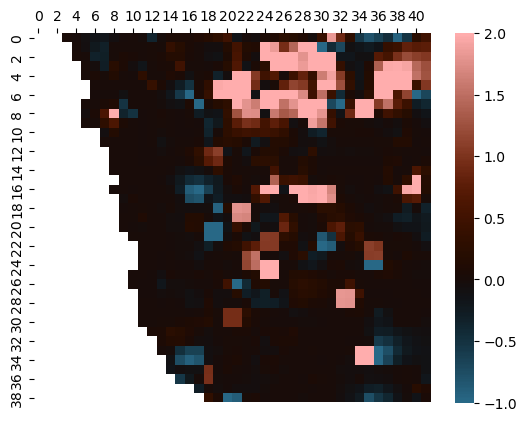

In [209]:
testMap_u("C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation Python Code/filtered_t5_2pass_small/filtered_t5_2pass_small_0090.txt")